**Aggregation Model**

In [2]:
## DATA AND PACKAGE IMPORT 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

## import data from particle concentration, backscatter, fluorescence
part_conc_490 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="4903659_binned_small_removed").iloc[:, 1:]
part_conc_699 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="6990636_binned_small_removed").iloc[:, 1:]

'''''

bbp_490 = pd.read_excel("BBP_binned.xlsx", sheet_name="4903659")
bbp_699 = pd.read_excel("BBP_binned.xlsx", sheet_name="6990636")

chla_fluor_490 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="4903659")
chla_fluor_699 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="6990636")

'''

temp_490 = pd.read_excel("Temp_binned.xlsx", sheet_name="4903659")
temp_699 = pd.read_excel("Temp_binned.xlsx", sheet_name="6990636")

sal_490 = pd.read_excel("Sal_binned.xlsx", sheet_name="4903659")
sal_699 = pd.read_excel("Sal_binned.xlsx", sheet_name="6990636")

# define depth array, time array (profiles)
depth = part_conc_490["depth_bin"].iloc[:60]
time_490 = pd.Series(range(1, 45))
time_699 = pd.Series(range(1, 78))            # probably won't use all of these profiles
#size_classes = part_conc_490.columns.to_numpy()[1:]
sizes = np.array([102,128,161,203,256,323,406,512,645,813,1020,1290,1630,2050,2580])

In [3]:
## SEPARATING FLOAT 490 PROFILES INTO INDIVIDUAL UVP6 DATAFRAMES 
# this does not contain backscatter or fluorescence yet

# Create container object
f490 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_490.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_490)]

skip_numbers = {13, 19}

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_490.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f490, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
#f490.p7.to_excel("f490.p7.xlsx", index=False)




## tada, doing the same with 6990636 
# this does not contain backscatter or fluorescence yet

# Create container object
f699 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_699.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_699)]

skip_numbers = {4, 17, 29, 53, 72}   # works too 11/6

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_699.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f699, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
# f699.p8.to_excel("f699.p8.xlsx", index=False)


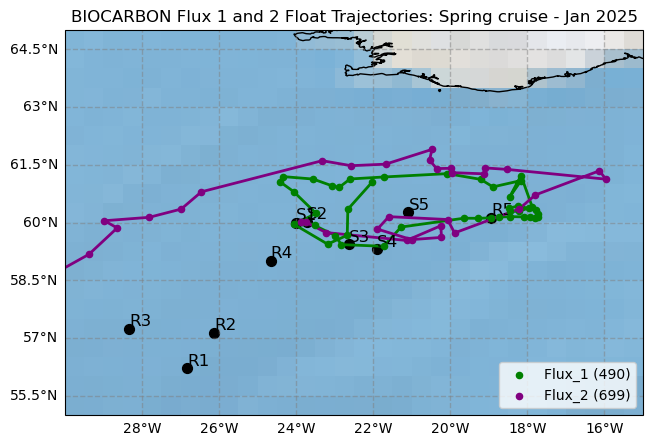

'"\n# Plotting particle concentration data with time\nfig, ax = plt.subplots()\n\n# Particle size 102 data for 490\n# time = (float numbers/dates)\n# y = (data from all profiles for f490)\n\n# Create figure and axes\nfig, ax = plt.subplots()\n\n# Plot the data\nax.plot(x, y, marker=\'o\')\nax.set_xlabel("X values")\nax.set_ylabel("Y values")\nax.set_title("Simple Line Plot")\nax.grid(True)\nplt.show()\n\n'

In [21]:
## Creating Figures for Presentation

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Argo float trajectories figure

float_data = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data")
lat = float_data.loc[:,"latitude"]
lon = float_data.loc[:,"longitude"]
lat.drop_duplicates(inplace = True), lon.drop_duplicates(inplace = True)

# index of first value of 699 is 44
lat_490 = lat[:44]
lon_490 = lon[:44]
lat_699 = lat[44:]
lon_699 = lon[44:]

# plotting on map

# Create a figure with a map projection
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.OCEAN) #facecolor='lightblue')
ax.stock_img()

gl = ax.gridlines(draw_labels=True,
                  linewidth=1,
                  color='gray',
                  alpha=0.5,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

s1_lat = 60.00016
s1_lon = -24.0004
s2_lat = 60.01922
s2_lon = -23.7194 
s3_lat = 59.43715
s3_lon = -22.6379 
s4_lat = 59.30469
s4_lon = -21.9108 
s5_lat = 60.26593
s5_lon = -21.0875

r1_lat = 56.21604
r1_lon = -26.8302
r2_lat = 57.12564
r2_lon = -26.1376
r3_lat = 57.23220
r3_lon = -28.3443
r4_lat = 59.01343
r4_lon = -24.6674 
r5_lat = 60.12009
r5_lon = -18.9309


# Plot the points
ax.scatter(lon_490, lat_490, color='green', s=20, label="Flux_1 (490)", transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(lon_699, lat_699, color='purple', s=20, label="Flux_2 (699)", transform=ccrs.PlateCarree(), zorder=5)

ax.legend(loc='lower right')

ax.scatter(s1_lon, s1_lat, color='black', s=50, label="S1", transform=ccrs.PlateCarree())
ax.scatter(s2_lon, s2_lat, color='black', s=50, label="S2", transform=ccrs.PlateCarree())
ax.scatter(s3_lon, s3_lat, color='black', s=50, label="S3", transform=ccrs.PlateCarree())
ax.scatter(s4_lon, s4_lat, color='black', s=50, label="S4", transform=ccrs.PlateCarree())
ax.scatter(s5_lon, s5_lat, color='black', s=50, label="S5", transform=ccrs.PlateCarree())

ax.scatter(r1_lon, r1_lat, color='black', s=50, label="R1", transform=ccrs.PlateCarree())
ax.scatter(r2_lon, r2_lat, color='black', s=50, label="R2", transform=ccrs.PlateCarree())
ax.scatter(r3_lon, r3_lat, color='black', s=50, label="R3", transform=ccrs.PlateCarree())
ax.scatter(r4_lon, r4_lat, color='black', s=50, label="R4", transform=ccrs.PlateCarree())
ax.scatter(r5_lon, r5_lat, color='black', s=50, label="R5", transform=ccrs.PlateCarree())


# Draw lines connecting points
ax.plot(lon_490, lat_490, color='green', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(lon_699, lat_699, color='purple', linewidth=2, transform=ccrs.PlateCarree())

# Set extent (optional: zoom to data)
ax.set_extent([
    -30, -15,
    55, 65
])

ax.text(s1_lon, s1_lat, "S1", fontsize=12, ha='left', va='bottom')
ax.text(s2_lon, s2_lat, "S2", fontsize=12, ha='left', va='bottom')
ax.text(s3_lon, s3_lat, "S3", fontsize=12, ha='left', va='bottom')
ax.text(s4_lon, s4_lat, "S4", fontsize=12, ha='left', va='bottom')
ax.text(s5_lon, s5_lat, "S5", fontsize=12, ha='left', va='bottom')
ax.text(r1_lon, r1_lat, "R1", fontsize=12, ha='left', va='bottom')
ax.text(r2_lon, r2_lat, "R2", fontsize=12, ha='left', va='bottom')
ax.text(r3_lon, r3_lat, "R3", fontsize=12, ha='left', va='bottom')
ax.text(r4_lon, r4_lat, "R4", fontsize=12, ha='left', va='bottom')
ax.text(r5_lon, r5_lat, "R5", fontsize=12, ha='left', va='bottom')


plt.title("BIOCARBON Flux 1 and 2 Float Trajectories: Spring cruise - Jan 2025")
plt.show()
                           
# lost my graph for the powerpoint - rewrite code if needed?

""""
# Plotting particle concentration data with time
fig, ax = plt.subplots()

# Particle size 102 data for 490
# time = (float numbers/dates)
# y = (data from all profiles for f490)

# Create figure and axes
fig, ax = plt.subplots()

# Plot the data
ax.plot(x, y, marker='o')
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.set_title("Simple Line Plot")
ax.grid(True)
plt.show()

"""

C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData

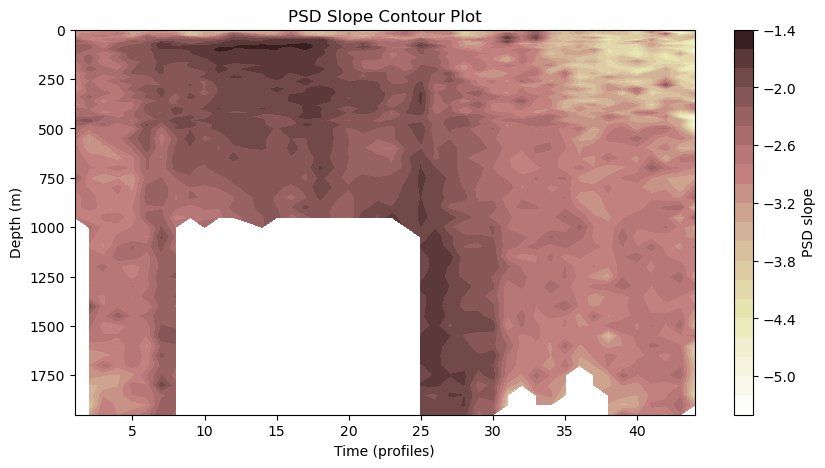

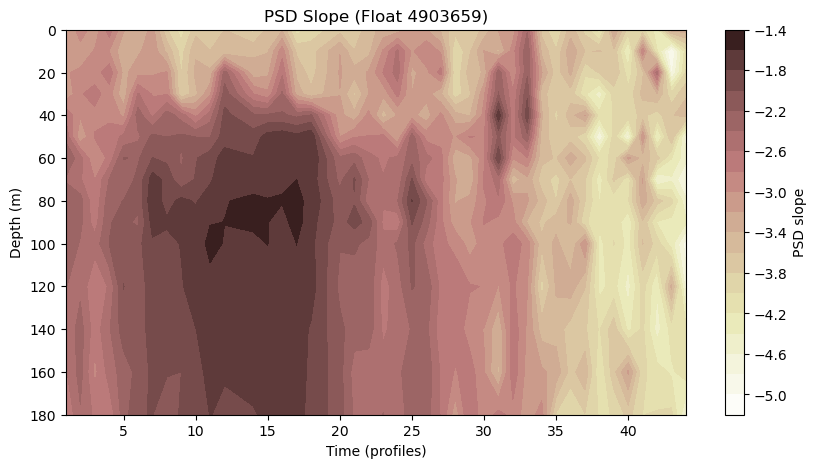

In [3]:
# BIOCARBON playing around
 

# # define parameters of particle size class, fluor, backscatter (maybe do a backscatter POC relationship curve conversion?), eventually turbulence


# input equations for particle dynamics - two size class approach?

# what float profiles match closest with the station locations?

# calculate PSD for each depth across size bins

def psd_slope(sizes, concentrations, use_cumulative=False):
    """
    Calculate PSD slope in log-log space.
    """

    import pandas as pd

    # Convert to pandas Series
    sizes = pd.Series(sizes).reset_index(drop=True)
    concentrations = pd.Series(concentrations).reset_index(drop=True)

    # Combine into DataFrame for easier handling
    df = pd.DataFrame({
        "sizes": sizes,
        "concentrations": concentrations
        })

    
    # Force numeric
    df["sizes"] = pd.to_numeric(df["sizes"], errors='coerce')
    df["concentrations"] = pd.to_numeric(df["concentrations"], errors='coerce')

    # Drop NaNs
    df = df.dropna()

    # Sort by size
    df = df.sort_values("sizes")

    # Normalize concentrations
    df["concentrations"] = df["concentrations"] / df["concentrations"].sum()

    # Optional cumulative
    if use_cumulative:
        df["concentrations"] = df["concentrations"].cumsum()

    # Remove invalid values for log
    df = df[(df["sizes"] > 0) & (df["concentrations"] > 0)]

    # Log transform (SAFE in pandas)
    df["log_sizes"] = df["sizes"].apply(lambda x: np.nan if x <= 0 else np.log10(x))
    df["log_conc"] = df["concentrations"].apply(lambda x: np.nan if x <= 0 else np.log10(x))


    df = df.dropna()

    # Linear regression using pandas (no np.polyfit)
    # slope = covariance(x,y) / variance(x)
    x = df["log_sizes"]
    y = df["log_conc"]

    slope = x.cov(y) / x.var()
    intercept = y.mean() - slope * x.mean()

    # Predicted values
    predicted = slope * x + intercept

    # R² calculation
    ss_res = ((y - predicted) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared
    }

test_p1_f490 = pd.to_numeric(f490.p1.iloc[0, 1:], errors='coerce')
#print(psd_slope(size_classes, test_p1_f490))



# Find all .pX attributes
p_keys = [key for key in f490.__dict__.keys() if key.startswith("p")]

all_results = {}

for p_key in p_keys:
    p_df = getattr(f490, p_key)

    # Extract sizes (column headers, skip first column)
    sizes = pd.to_numeric(p_df.columns[1:], errors='coerce')

    slopes = []

    # Loop through ALL rows (depth bins)
    for row in range(p_df.shape[0]):
        concentrations = pd.to_numeric(p_df.iloc[row, 1:], errors='coerce')

        res = psd_slope(sizes, concentrations)
        slopes.append(res["slope"])

    # Store results for this dataset
    all_results[p_key] = slopes

# Create final DataFrame
slope_df = pd.DataFrame(all_results)


# just need to plot and have a look
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y)

# Z values
Z = slope_df.to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope Contour Plot")

# Invert depth axis (common in oceanography)
plt.gca().invert_yaxis()

plt.show()



# Plot from first 200 m 
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()
Y_shallow = Y[0:15]

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y_shallow)     # specify range that is length of Y and X

# Z values
Z = slope_df.iloc[:15, :].to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.plot()
plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope (Float 4903659)")

# Invert depth axis
plt.gca().invert_yaxis()

plt.show()


**Steady-State Model (single profile):**

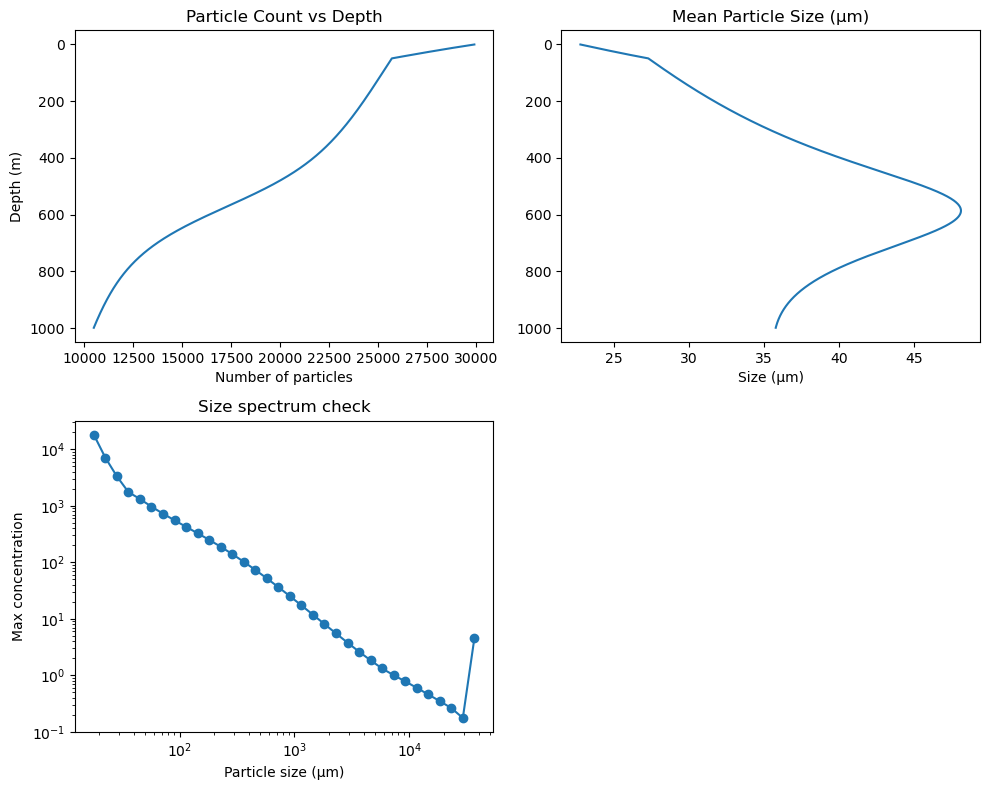

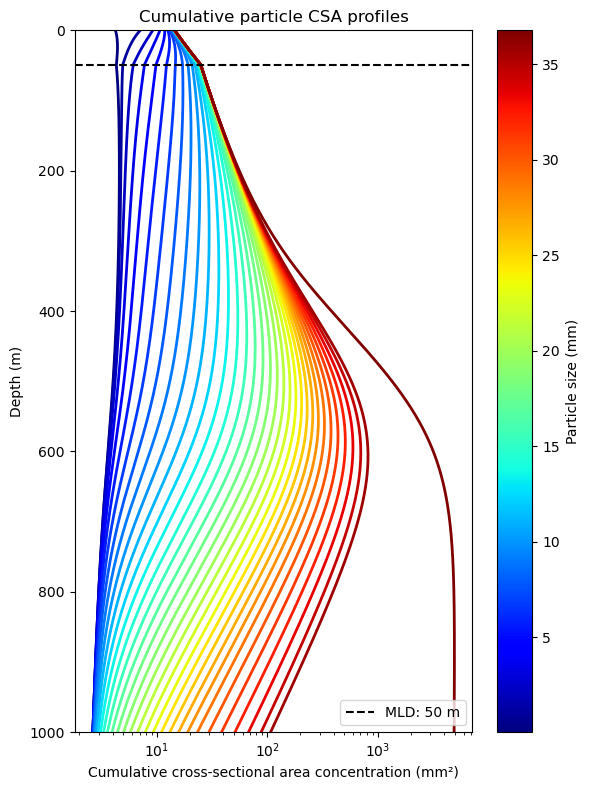

In [46]:
# ------------------------------
# CREATES SIZE BINS
# ------------------------------
size_bounds = 2 ** np.arange(4, 15 + 1/3, 1/3)    # starting size 16 um, up to 40 mm, in 1/3 log power increments
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:])  # bin centres

radius = size_bins / 2.0  # microns               
radius_m = radius * 1e-6                          # converts radius to m for sinking velocity

n_bins = len(size_bins)                           # 35 size classes

# ---------------------------------------------------
# INITIAL PARTICLE NUMBERS, DISTRIBUTION + PROPERTIES
# ---------------------------------------------------
N0 = 30000                                        # starting no. of particles

# all particles start in smallest bin
#C = np.zeros(n_bins)
#C[0] = N0

# power-law slope for starting particle distribution
slope = 3.5                                       # n(D) ~ D^-slope, where slope is the exponent of the power-law distribution
# generate power-law distribution
C = (size_bins / size_bins[0]) ** (-slope)
# scale to total number of particles
C = C / np.sum(C) * N0

# Parameters
Df = 2  # fractal dimension                
rho_f = 1025    # seawater density (kg/m^3)                      
mu = 1e-3       # viscosity (Pa·s)
g = 9.81        # force due to gravity
stick = 0.5

# Density based on fractal dimension
def particle_density(r):
    # reference radius (smallest particle)
    r0 = radius_m[0]
    rho0 = 1050   # density at smallest size

    rho_eff = rho0 * (r / r0)**(Df - 3)

    return max(rho_eff, rho_f + 1)   # prevent particle density < seawater density


# Turbulent shear values                       ## will adapt shear values above MLD and another below MLD, this might need to be included as W m2 or similar
surface_G = 10.0
deep_G = 1.0
MLD = 50  # mixed layer depth (m)    # adapt so this can be read from the relevant float profile/whichever is selected as reference

# ---------------------------------------------------
# DEFINE KERNELS
# ---------------------------------------------------

# experimenting with fractal dimension scaling for settling velocity
def settling_velocity(r):
    rho_eff = particle_density(r)
    return (2/9) * (rho_eff - rho_f) * g * r**2 / mu

def shear_rate(depth):
    return surface_G if depth < MLD else deep_G

def jackson_kernel(r1, r2, depth):
    G = shear_rate(depth)
    
    beta_shear = 1.3 * G * (r1 + r2)**3     # shear aggregation
    
    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)
    beta_settle = np.pi * (r1 + r2)**2 * abs(w1 - w2)  # diff. settling

    return beta_shear + beta_settle         # total aggregation
    # can add brownian motion if we think it would be relevant

dz = 1                                    # change in depth (adjust to capture different changes in depth from UVP sample rate?)
z_max = 1000                                # max depth
nz = int(z_max / dz)                        # number of depth steps

# store concentrations at each depth
C_profile = np.zeros((nz, n_bins))       

particle_counts = []
mean_sizes = []
depths = []

# ---------------------------------------------------
# MAIN MODEL LOOP
# ---------------------------------------------------

for z_step in range(nz):
    depth = z_step * dz
    
    C_new = np.zeros_like(C)

    for i in range(n_bins):                        # compares every size bin pair
        for j in range(i, n_bins):

            if C[i] == 0 or C[j] == 0:             # skip if no particles
                continue

            r1, r2 = radius_m[i], radius_m[j]      # collision rates

            beta = jackson_kernel(r1, r2, depth)

            # convert depth step to time via sinking
            w = settling_velocity((r1 + r2) / 2)
            if w <= 0:
                continue

            dt_local = dz / w

            collisions = beta * C[i] * C[j] * dt_local   # no. of collisions

            if i == j:
                collisions *= 0.5  # avoid double counting

            # sticking probability
            agg = stick * collisions

            # ---- limit aggregation ----
            if i == j:
                agg = min(agg, C[i] / 2)      # conserves particle removal
            else:
                agg = min(agg, C[i], C[j])

            # remove particles
            C_new[i] -= agg                   # removes particle from original bin after aggregation
            C_new[j] -= agg

            # new aggregated size
            new_size = size_bins[i] + size_bins[j]

            k = np.searchsorted(size_bins, new_size)

            # ---- bin assignment ----
            if k >= n_bins:
                C_new[-1] += agg              # interpolate bins (reduce gaps in spectrum)

            elif k == 0:
                C_new[0] += agg

            else:
                lower = size_bins[k-1]
                upper = size_bins[k]

                if upper == lower:
                    frac = 0.5
                else:
                    frac = (new_size - lower) / (upper - lower)

                C_new[k] += agg * frac
                C_new[k-1] += agg * (1 - frac)

    # update concentrations
    C += C_new
    
    # diffusion between size bins
    diffusion = 0.02  # small smoothing factor
    C_diff = np.zeros_like(C)

    for i in range(1, n_bins - 1):
        spread = diffusion * C[i]

        C_diff[i] -= 2 * spread
        C_diff[i-1] += spread
        C_diff[i+1] += spread

    C += C_diff

    # prevent negatives
    C[C < 0] = 0

    # save profile at this depth
    C_profile[z_step, :] = C.copy()     


    # OPTIONAL: allow bin growth (dynamic classes)
    #size_bins = size_bins * (1 + 0.001 * dz)

    # track diagnostics
    total_particles = np.sum(C)
    mean_size = np.sum(C * size_bins) / total_particles if total_particles > 0 else 0

    particle_counts.append(total_particles)
    mean_sizes.append(mean_size)
    depths.append(depth)


## Plotting Figures
    
plt.figure(figsize=(10, 8))

# Particle count vs depth

plt.subplot(2, 2, 1)
plt.plot(particle_counts, depths)
plt.gca().invert_yaxis()
plt.title("Particle Count vs Depth")
plt.xlabel("Number of particles")
plt.ylabel("Depth (m)")

# Mean particle size vs depth

plt.subplot(2, 2, 2)
plt.plot(mean_sizes, depths)
plt.gca().invert_yaxis()
plt.title("Mean Particle Size (µm)")
plt.xlabel("Size (µm)")

# Size Bin behaviour plot

plt.subplot(2, 2, 3)
plt.plot(size_bins, np.max(C_profile, axis=0), marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Particle size (µm)")
plt.ylabel("Max concentration")
plt.title("Size spectrum check")

plt.tight_layout()
plt.show()



# Individual Concentrations per size class over depth
# Calculating Cross-sectional area

# convert size to radius in mm
radius_mm = (size_bins / 2.0) / 1000.0  

# cross-sectional area per particle (mm²)
area_per_particle = np.pi * radius_mm**2  

# compute CSA concentration at each depth (nz x n_bins)
cross_sectional_area = C_profile * area_per_particle



# ---------------------------
# CUMULATIVE STACK PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 8))

# ---- TRANSPOSE FIRST ----
csa_T = cross_sectional_area.T   # (size_bin, depth)

# ---- cumulative stack ----
cumulative = np.cumsum(csa_T, axis=0)

# colour gradient
cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, len(size_bins)))

# plot each size boundary
for i in range(len(size_bins)):
    ax.plot(cumulative[i, :], depths,
            color=colors[i],
            linewidth=2)

# MLD line
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD: {MLD} m")

# formatting
ax.set_xlabel("Cumulative cross-sectional area concentration (mm²)")
ax.set_ylabel("Depth (m)")
ax.set_ylim(0, z_max)
ax.set_xscale("log")
ax.set_title("Cumulative particle CSA profiles")

ax.legend(loc="lower right")

# colourbar
norm = plt.Normalize(vmin=min(size_bins/1000), vmax=max(size_bins/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Particle size (mm)")

ax.invert_yaxis()
plt.tight_layout()
plt.show()


# if bin growth is needed
# size_bins = size_bins * (1 + growth_rate * dz)


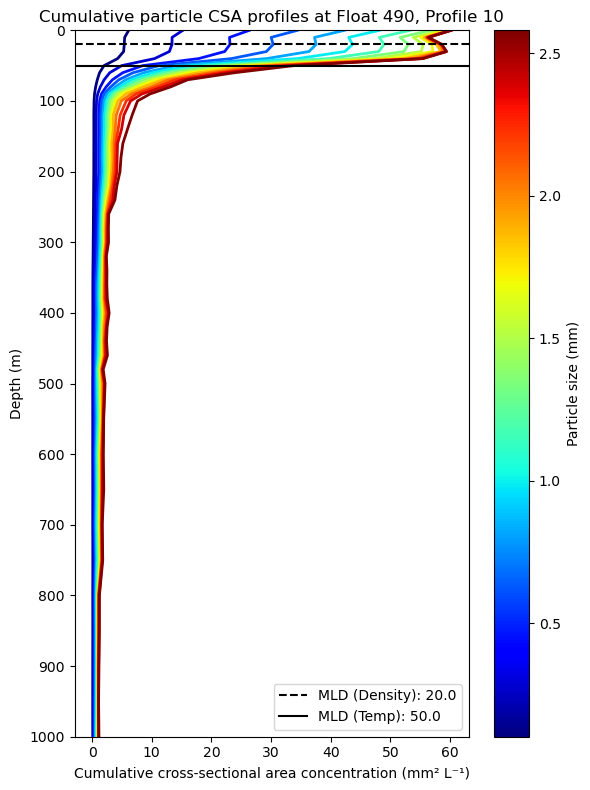

In [ ]:
## OBSERVATIONAL DATA DEPTH PROFILE (DIAGNOSTIC FIGURE) 

# pick profile that will be used as a diagnostic, maybe close to super station or something
# would need to calculate cross-sectional area of particles (method in notebook) for each size class
# then expand that over depth

mid_size = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data").iloc[3:18, 16]     # (size_mid_um)
mid_size.drop_duplicates()
mid_size = mid_size.to_numpy(dtype=float)
mid_size[-1] = 2580

# Choose which float and profile to investigate
UVP6_float = 490
number = 10
profile = f490.p10  # here you can change the float profile, could probably tidy this up more so that when you write your variable name it updates UVP6_float and number automatically but not a good use of time

float_temp = temp_490["P10"]
float_sal = sal_490["P10"]


# Apply mid-size scaling
# shape = (n_sizes, n_depth)
concs = np.array([profile[s] for s in sizes], dtype=float)
circle_scale = np.pi * ((mid_size / 2) ** 2)  # calculate the cross-sectional area of a circle for each mid-size
cross_sectional_area = (concs * circle_scale[:, None]) / 1000000

## calculate mixed layer depth depending on profile
# extract temperature and density from relevant biogeochemical float data
# does that mean binning the temperature and density data to match the particle concentration depth bins?

import gsw
float_temp_CT = gsw.CT_from_t(float_sal, float_temp, depth)
float_density = gsw.rho(float_sal, float_temp_CT, depth) - 1000                  ## look at this as either a) how I calculated density or b) the pressure values I fed into it, is wrong, as density MLD seems to be very shallow
                                                                              ## additionally look at the binning of temperature and density, maybe add a secondary y axis for continous depth to assess more accurately

# reference values = first element
ref_density = float_density[0]
ref_temp = float_temp[0]

# find first index where threshold is met
density_diff = np.abs(float_density - ref_density)
temp_diff = np.abs(float_temp - ref_temp)

MLD_density_idx = np.where(density_diff >= 0.03)[0][0]
MLD_temp_idx = np.where(temp_diff >= 0.2)[0][0]

MLD_density = depth[MLD_density_idx] + 10      # correction for surface? As the array calculates 20 m as 10 m
MLD_temp = depth[MLD_temp_idx] + 10


# Plotting Cumulative stack

fig, ax = plt.subplots(figsize=(6,8))

# cumulative sum across size bins
cumulative = np.cumsum(cross_sectional_area, axis=0)

# create a colour gradient
cmap = plt.cm.jet   # you can change this (plasma, turbo, etc.)
colors = cmap(np.linspace(0, 1, len(sizes/1000)))

# plot each cumulative boundary as a line
for i, s in enumerate(sizes):
    ax.plot(cumulative[i], depth,
            color=colors[i],
            linewidth=2)
    
# Add mixed layer depth
ax.axhline(y = MLD_density, color="black", linestyle="--", label=f"MLD (Density): {MLD_density}")    # as straight line across
ax.axhline(y = MLD_temp, color="black", linestyle="-", label=f"MLD (Temp): {MLD_temp}")    # as straight line across

ax.set_xlabel("Cumulative cross-sectional area concentration (mm² L⁻¹)")
ax.set_ylabel("Depth (m)")
ax.set_ylim(0, 1000)
ax.set_yticks(np.linspace(0, 1000, 11))
ax.set_title(f"Cumulative particle CSA profiles at Float {UVP6_float}, Profile {number}")
ax.legend(loc="lower right")

# Colourbar
norm = plt.Normalize(vmin=min(sizes/1000), vmax=max(sizes/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Particle size (mm)")

ax.invert_yaxis()

plt.tight_layout()
plt.show()
